In [48]:
import pickle
import numpy as np
from figure import * 
import cmasher as cmr
import seaborn as sns 
import matplotlib.ticker as tkr

formatter = tkr.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-2, 2))

[None, None, None, None, None, None, None, None, None, None, None]

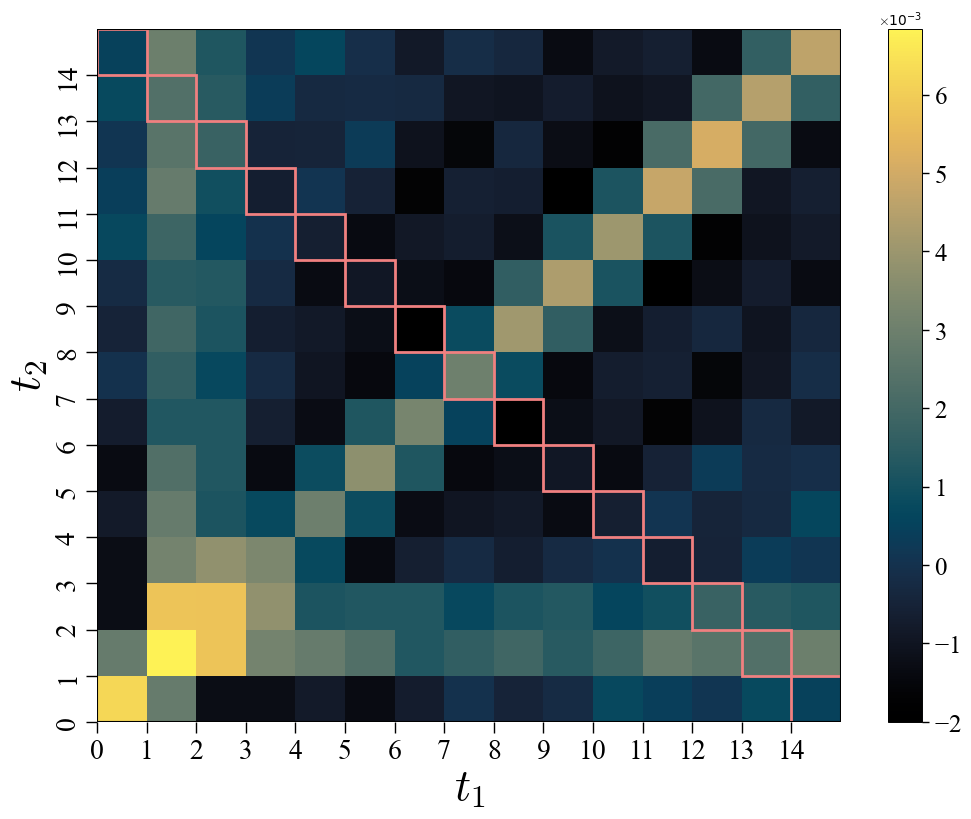

In [49]:
with open('mps_two_time_acf', 'rb') as f: 
    mps_two_time = pickle.load(f)

fig, ax = plt.subplots(figsize=(12,9))
max_time_steps = 15
x, y = np.meshgrid(np.arange(max_time_steps), np.arange(max_time_steps))
plt.rcParams['mathtext.fontset'] ='cm' 
cmap = 'cmr.eclipse'
heatmap = sns.heatmap(np.real(mps_two_time)/(16*40), cbar=True, cmap=cmap,rasterized=True,
                       cbar_kws={"format": formatter})
time_steps = 14
ax.set_xticks(np.arange(0,time_steps+1,1),np.arange(0,time_steps+1,1))
ax.set_yticks(np.arange(0,time_steps+1,1),np.arange(0,time_steps+1,1))
labels = ax.get_yticklabels() + ax.get_xticklabels()
[label.set_fontname('Times new roman') for label in labels]
[label.set_weight('normal') for label in labels]
ax.tick_params(axis='y', labelsize =20, direction='out', length=8, width=1,  left=True)
ax.tick_params(axis='x', labelsize =20, direction='out', length=8, width=1,  bottom=True)
ax.set_xlabel('$t_1$', font=font1, fontsize= 32)
ax.set_ylabel('$t_2$', font=font1, fontsize= 32)
ax.hlines(0, 0,41, color='black'), ax.hlines(15, 0,41, color='black')
ax.vlines(0, 0,41, color='black'), ax.vlines(15, 0,41, color='black')
ax.invert_yaxis()
highlight_cells = [(i, 14-i) for i in range(15)]
# Draw rectangles (frames) around the selected cells
for (i, j) in highlight_cells:
    ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='lightcoral', lw=2))

cbar = heatmap.collections[0].colorbar  # Access the colorbar
cbar.outline.set_edgecolor('black')  # Set border color
cbar.outline.set_linewidth(0.7)   
cbar.ax.tick_params(length=5, width=1, color='black',labelsize=18)
labels = cbar.ax.get_yticklabels() 
[label.set_fontname('Times new roman') for label in labels]
[label.set_weight('normal') for label in labels]


In [50]:
#### bootstrapping the depolarizing rate #### 
mean, std = [], []
for index in range(7):
    Even_depo = np.zeros(shape=(4*(index+1),))
    for i in range(100):
        with open('bootstrapped_even_depo/bootstrapped_even_depo_'+str(i), 'rb') as f: 
            even_depo = pickle.load(f)
        Even_depo += even_depo[index]
    Even_depo = Even_depo/100

    Odd_depo = np.zeros(shape=(4*index+2))
    for i in range(100):
        with open('bootstrapped_odd_depo/bootstrapped_odd_depo_'+str(i), 'rb') as f: 
            odd_depo = pickle.load(f)
        Odd_depo += odd_depo[index]
    Odd_depo = Odd_depo/100

    # create the JJ matrix for each bootstrapped datat 
    total_lc = []
    for job in range(100):    
        with open('bootstrapped_even/bootstrapped_even_'+str(job), 'rb') as f: 
            even = pickle.load(f)
        with open('bootstrapped_odd/bootstrapped_odd_'+str(job), 'rb') as f: 
            odd = pickle.load(f)
        depo_jj_matrix  = np.zeros(shape=(4*index+3)) 
        pairs = 2*(index+1)
        for pair in range(pairs):
            depo_iz = even[index][pair][0] / Even_depo[2*pair+1]
            depo_zi = even[index][pair][1] / Even_depo[2*pair]
            depo_jj_matrix[pair*2]= (depo_iz-depo_zi)*-2/16
        start = 1
        pairs = 2*index +1 
        for pair in range(pairs): 
            depo_iz = odd[index][pair][0] / Odd_depo[2*pair+1]
            depo_zi = odd[index][pair][1] / Odd_depo[2*pair]
            depo_jj_matrix[start+pair*2] = (depo_iz-depo_zi)*-2/16
        total_lc.append(np.sum(depo_jj_matrix))
    mean.append(np.mean(total_lc)/40), std.append(np.std(total_lc)/40)
    # print(np.mean(total_lc), np.std(total_lc))

# last data point from one time 
mean.append(1.12222470e-4)
std.append(2.51632850e-4)

In [51]:
mps_data = np.array([np.complex128(0.003021282484396548+0.0005660696607633174j),
 np.complex128(-0.002002911999799513+0.001433298414570878j),
 np.complex128(-0.0009302442246942003+2.3720161365239696e-05j),
 np.complex128(-0.0006333886246517734-0.0010842134803811729j),
 np.complex128(-0.0006811730396538442-0.0010046215965810723j),
 np.complex128(0.001760761272382381-0.0017503566565413723j),
 np.complex128(0.0023277448227428388+0.0005751842863460564j),
 np.complex128(0.00047948294342356327+0.0028773736964016255j)])

Fig. 2b

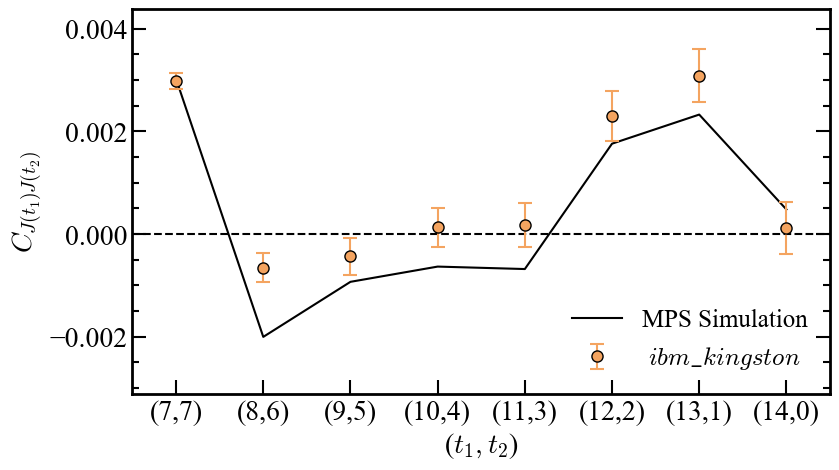

In [52]:
fig, ax = plt.subplots(figsize=(9,5)) 
font25 = {'family': 'Times new roman','weight': 'normal','size': 18}
plt.rcParams['mathtext.fontset'] ='cm'  
color = 'cmr.eclipse'
cmap = cmr.take_cmap_colors(color, 5, cmap_range=(0.2, 0.9), return_fmt='hex')
ax.errorbar(np.arange(8), np.array(mean), yerr=np.array(std)*2,  markersize=8,
            color = 'sandybrown', capsize=5, capthick= 1.5, fmt='o',label =  
            ' $ibm\_kingston$', markeredgecolor='black', zorder=5)
ax.plot(np.arange(8), np.real(mps_data),label= 'MPS Simulation', color='black')
adjust_ax(ax)
ax.set_xticks([])
ax.set_xticks(np.arange(0,8,1),['('+str(14-i)+','+str(i)+')' for i in range(7,-1,-1)])
ax.tick_params(axis='x', which='minor', bottom=False)
ax.set_ylim(-0.5/(40*4), 0.7/(40*4))
ax.set_xlim(-0.5, 7.5)
ax.hlines(0, -0.5, 7.5, color='black', ls='--')
ax.set_xlabel('($t_1, t_2$)', font='Times new roman', fontsize=20)
ax.set_ylabel('$ C_{J(t_1)J(t_2)} $', font='Times new roman', fontsize=20)
ax.legend(prop=font25, frameon=False, loc =4)